# Topical Lectures, Controls 
## Drone control, part 3: basic control
Andreas Freise, Bas Swinkels 27.05.2026

In this notebook, we will, step by step, develop the control for the drone. We will define and test functions that take position and velocity information from the drone and compute `feedback' signals, i.e. new voltages for both drone motors.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import module
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) 

# This time we want inline plotting (non-interactive)
%matplotlib inline

# Don't forget to set the name string to your own name
MyName = "Andreas"

First we can write a utiity function that uses the parameters from the system identificaition tasks in order to compensate for the small differences between different drones. Bu using this function to apply our feedback signal, we should be able to write control functions ignoring these details.

In [2]:
# Measured parameters for the Crazyflie-scale drone (SI units throughout).
# These would normally come from the student2 system-identification notebook.
V_left_offset = -0.0027   # throttle units; cancels left/right asymmetry
V_hover = 0.5297          # per-motor throttle at hover (= M*g/2 / amp)
V_max = 1.0               # throttle range upper bound
V_min = 0                 # motors are single-direction

# Common-mode / differential decomposition for motor mixing.
# Total motor command must stay in [V_min, V_max]; the differential is
# bounded by the headroom that the common-mode thrust leaves on each side.

def set_v(drone, _V_left, _V_right):
    V_left = V_hover + _V_left + V_left_offset
    V_right = V_hover + _V_right
    fb_z = (V_left + V_right) / 2
    fb_phi = (V_left - V_right) / 2
    fb_z = max(V_min, min(fb_z, V_max))
    headroom = min(fb_z - V_min, V_max - fb_z)
    fb_phi = max(-headroom, min(fb_phi, headroom))
    drone.set_V(fb_z + fb_phi, fb_z - fb_phi)

def set_v_nohover(drone, _V_left, _V_right):
    V_left = _V_left + V_left_offset
    V_right = _V_right
    fb_z = (V_left + V_right) / 2
    fb_phi = (V_left - V_right) / 2
    fb_z = max(V_min, min(fb_z, V_max))
    headroom = min(fb_z - V_min, V_max - fb_z)
    fb_phi = max(-headroom, min(fb_phi, headroom))
    drone.set_V(fb_z + fb_phi, fb_z - fb_phi)

def zphi2V(fb_z, fb_phi):
    V_left = fb_z + fb_phi
    V_right = fb_z - fb_phi
    return V_left, V_right


Now we want to develop the control systems for the drone.

We will need several levels of control loops that we can develop in sequence:
- tilt control for stabilising the angle to a user-defined value
- hover control for moving the drone up or down to a set altitude
- control for the left-right motion of the drone. This loop must use the tilt control as it's `actuator'.

For the control design we switch on wind (```wind=True```), because this makes it easier to see if our controls are having an effect.

# Tilt control

At first we can write another utility function that takes as in input the desired feedback in vertical direction and for tilt and returns the voltages for the individual rotors, for example like this:

In [3]:
# Convert vertical and tilt feedback signal into V_left and V_right
# Again this simple signal combination might not always be optimal but
# good for getting started.
def zphi2V(fb_z, fb_phi):
    V_left = fb_z + fb_phi
    V_right = fb_z - fb_phi
    return V_left, V_right

Now we can define a function that generates the feedback signal for tilt.

## Proportioanal feedback

At first we will try proportional conttrol: we can measure the difference between the current tilt angle ```phi``` and the set angle ```phi0```, and provide feedback which is proportional to that distance. This sounds good, we will have a larger signal the further we are away from the set point, and when we are at the set point, the feedback will become zero.

In [4]:
# Proportional feedback
def phi_proportional_feedback(phi, phi0):
    # phi: current tilt of the drone [rad]
    # phi0: desired tilt of the drone [rad]
    p = 0.02 # the so-called \'proportional gain\' of the controller
    fb = (phi-phi0) * p # feedback signal
    return fb


In [5]:
# testing our new feedback function

drone = module.Drone(name=MyName, wind=True, flight_range=[0,0,0,0],
                     drag_t=0, drag_r=0)
N = 300
results = np.zeros([N,14])
V_left=0
V_right=0
phi0=np.deg2rad(20)
set_v(drone,V_left,V_right)

for i in range(N):
    state = drone.update()
    results[i,0:12] = module.state_to_array(state)
    results[i,12:14] = [V_left,V_right]

    phi = state.phi
    dphi = state.dphi

    phi_fb = phi_proportional_feedback(phi,phi0)
    V_left, V_right = zphi2V(0, phi_fb)
    set_v(drone,V_left, V_right)


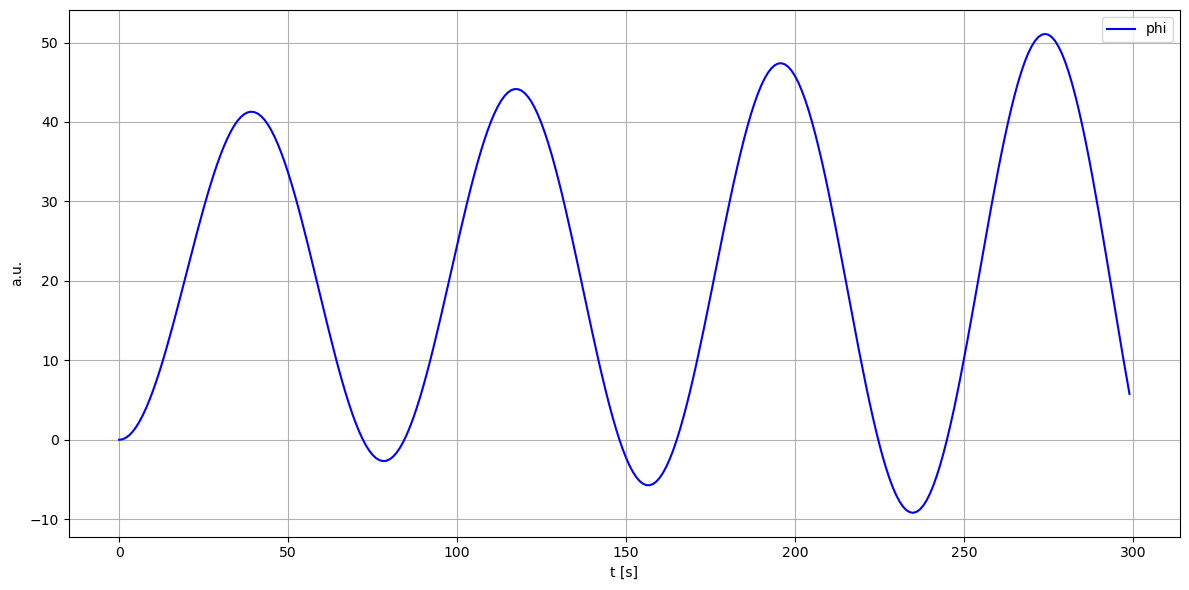

In [6]:
start=0
t = results[start:,0]
y = results[start:,1]
z = results[start:,2]
phi = results[start:,3]
dphi = results[start:,6]
fig, ax = plt.subplots(1, figsize=(12,6))
plt.plot(np.rad2deg(phi), 'b', label="phi")
ax.set_xlabel("t [s]")
ax.set_ylabel("a.u.")
plt.grid()
plt.legend()
plt.tight_layout()

We can see that the drone angle is oscillation around the set point `phi0'. You should play with the proportional gain ```p``` to see how the behaviour of the loop changes with the gain.

Even without knowing much about PID controllers, we can guess that our feedback loop is missing a **damping** term. This is something we can add easily, because the drone reports its velocity.

## Proportional feedback with damping

In [7]:
# Damped proportional feedback
def phi_damped_feedback(phi, dphi, phi0):
    p = 0.1   # p for proportional gain
    d = 0.02  # d for differential gain
    fb = (phi-phi0) * p + d * dphi
    return fb


In [8]:
drone = module.Drone(name=MyName, wind=True, flight_range=[0,0,0,0],
                     drag_t=0, drag_r=0)
N = 300
results = np.zeros([N,14])
V_left=0
V_right=0
phi0=np.deg2rad(45)
set_v(drone,V_left,V_right)

for i in range(N):
    state = drone.update()
    results[i,0:12] = module.state_to_array(state)
    results[i,12:14] = [V_left,V_right]

    phi = state.phi
    dphi = state.dphi

    phi_fb = phi_damped_feedback(phi,dphi,phi0)
    V_left, V_right = zphi2V(0, phi_fb)
    set_v(drone,V_left, V_right)


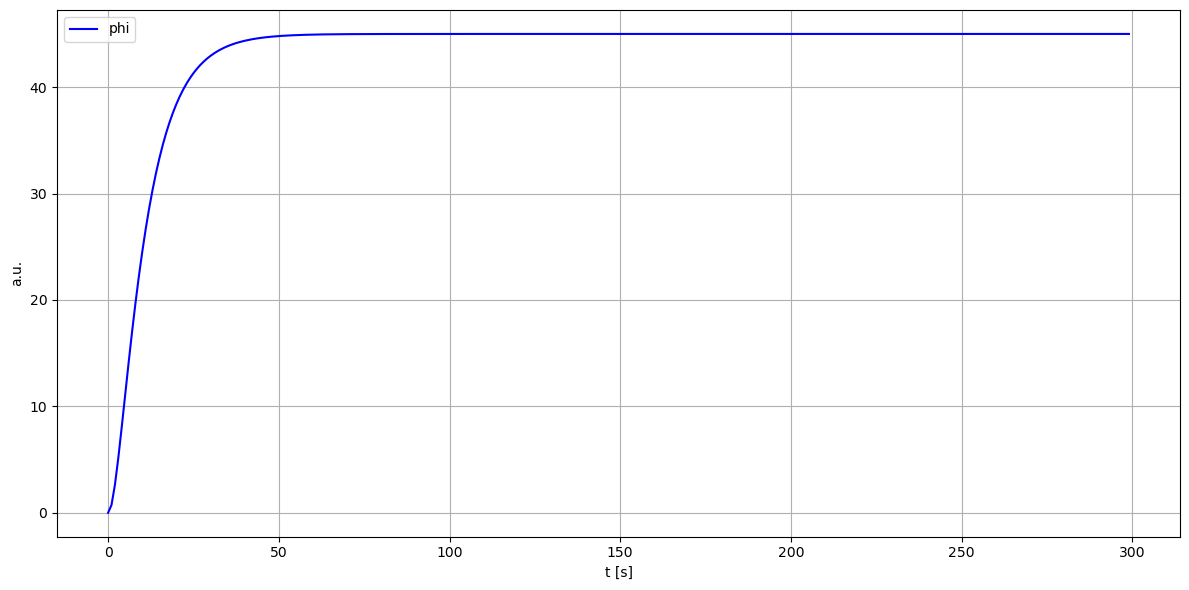

In [9]:
start=0
t = results[start:,0]
y = results[start:,1]
z = results[start:,2]
phi = results[start:,3]
dphi = results[start:,6]
fig, ax = plt.subplots(1, figsize=(12,6))
plt.plot(np.rad2deg(phi), 'b', label="phi")
ax.set_xlabel("t [s]")
ax.set_ylabel("a.u.")
plt.grid()
plt.legend()
plt.tight_layout()

Much better! The control can be optimised by changed the two gains ```p``` and ```d``` such that the drone reaches the set point ```phi0``` in the shortest amount of time without any overshoot. This is similar to applying critical damping in an oscillator.

With this loop we can already achieve a very good response of the drone. For this loop there is no apparent need to add an **integrator** (the `I' in PID). However, we will see where this could be usefil in the vertical control below.

# Vertical control

Next we want to design a loop that holds the drone at a set vertical position ```z0```. We already know that we need at least a damped feedback function. We can relax the clamping of the drone by using a ```flight_range``` of ```[0, -500, 0, 500]``` which allows the drone up and down but no sideways motion. We must keep the tilt control enaged however. Make sure to experiment with large values for ```z0```.

In [10]:
# tilt feedback loop
def phi_damped_feedback(phi, dphi, phi0):
    p = 0.1
    d = 0.02
    fb = (phi-phi0) * p + d * dphi
    return fb

# vertical feedback loop
def z_damped_feedback(z, dz, z0):
    p = -1.0
    d = 0.5
    fb = (z-z0) * p - d * dz
    return fb


In [11]:
drone = module.Drone(name=MyName, wind=True, flight_range=(0, -3, 0, 3),
                     drag_t=0, drag_r=0)
N = 1000
results = np.zeros([N,14])
V_left=0
V_right=0
phi0=np.deg2rad(0)
z0 = 1
set_v(drone,V_left,V_right)

for i in range(N):
    state = drone.update()
    results[i,0:12] = module.state_to_array(state)
    results[i,12:14] = [V_left,V_right]

    z = state.z
    dz = state.dz
    phi = state.phi
    dphi = state.dphi

    phi_fb = phi_damped_feedback(phi,dphi,phi0)
    z_fb = z_damped_feedback(z,dz,z0)
    V_left, V_right = zphi2V(z_fb, phi_fb)
    set_v(drone,V_left, V_right)


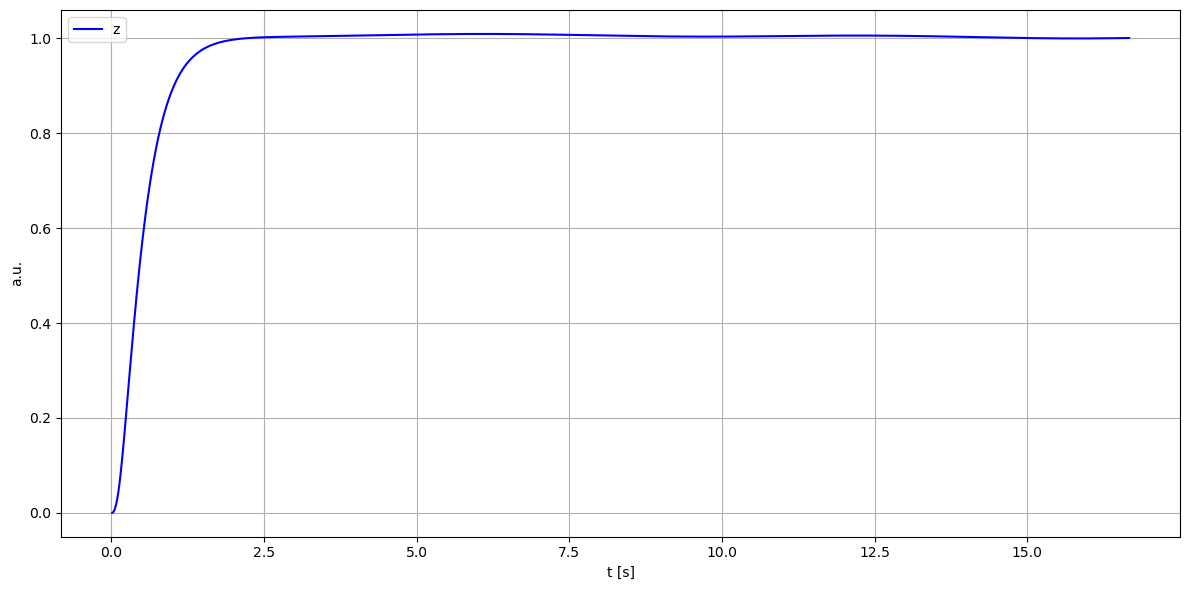

In [12]:
start=0
t = results[start:,0]
y = results[start:,1]
z = results[start:,2]
dz = results[start:,5]
fig, ax = plt.subplots(1, figsize=(12,6))
plt.plot(t, z, 'b', label="z")
ax.set_xlabel("t [s]")
ax.set_ylabel("a.u.")
plt.grid()
plt.legend()
plt.tight_layout()

After playing around with the gains you should be able to control the z position quickly, similar to the angle above.

# Removing the hover feedforward

So far we have been relying on the `set_v` helper to add the hover voltage `V_hover` for us, so that our PD controller only has to correct small deviations around hover. As an experiment, let's switch to the alternative `set_v_nohover` function that does *not* include the `V_hover` offset, and run the same PD control function again:

In [13]:
# Same idea as set_v, without the V_hover feedforward.
def set_v_nohover(drone, _V_left, _V_right):
    V_left = _V_left + V_left_offset
    V_right = _V_right
    fb_z = (V_left + V_right) / 2
    fb_phi = (V_left - V_right) / 2
    fb_z = max(V_min, min(fb_z, V_max))
    headroom = min(fb_z - V_min, V_max - fb_z)
    fb_phi = max(-headroom, min(fb_phi, headroom))
    drone.set_V(fb_z + fb_phi, fb_z - fb_phi)


In [14]:
drone = module.Drone(name=MyName, wind=True, flight_range=(0, -3, 0, 3),
                     drag_t=0, drag_r=0)
N = 3000
results = np.zeros([N,14])
V_left=0
V_right=0
phi0=np.deg2rad(0)
z0 = 1.5
set_v_nohover(drone,V_left,V_right)

for i in range(N):
    state = drone.update()
    results[i,0:12] = module.state_to_array(state)
    results[i,12:14] = [V_left,V_right]

    z = state.z
    dz = state.dz
    phi = state.phi
    dphi = state.dphi

    phi_fb = phi_damped_feedback(phi,dphi,phi0)
    z_fb = z_damped_feedback(z,dz,z0)
    V_left, V_right = zphi2V(z_fb, phi_fb)
    set_v_nohover(drone,V_left, V_right)


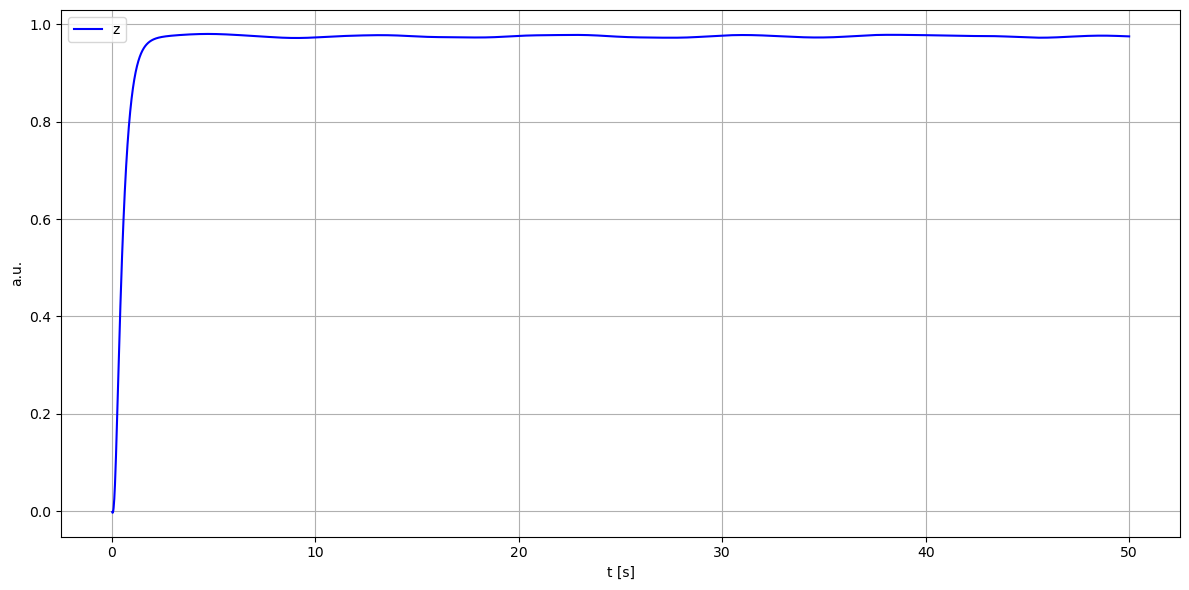

In [15]:
start=0
t = results[start:,0]
y = results[start:,1]
z = results[start:,2]
dz = results[start:,5]
fig, ax = plt.subplots(1, figsize=(12,6))
plt.plot(t, z, 'b', label="z")
ax.set_xlabel("t [s]")
ax.set_ylabel("a.u.")
plt.grid()
plt.legend()
plt.tight_layout()

At first glance the result looks the same, but if we zoom into the plot when the set point has apparently been reached, we see that we never actually reach the set point. This is simply because the feedback is proportional to the error signal ```z-z0```, which goes to zero when we approach the set point, and when close enough becomes too small to overcome the gravitational acceleration. 

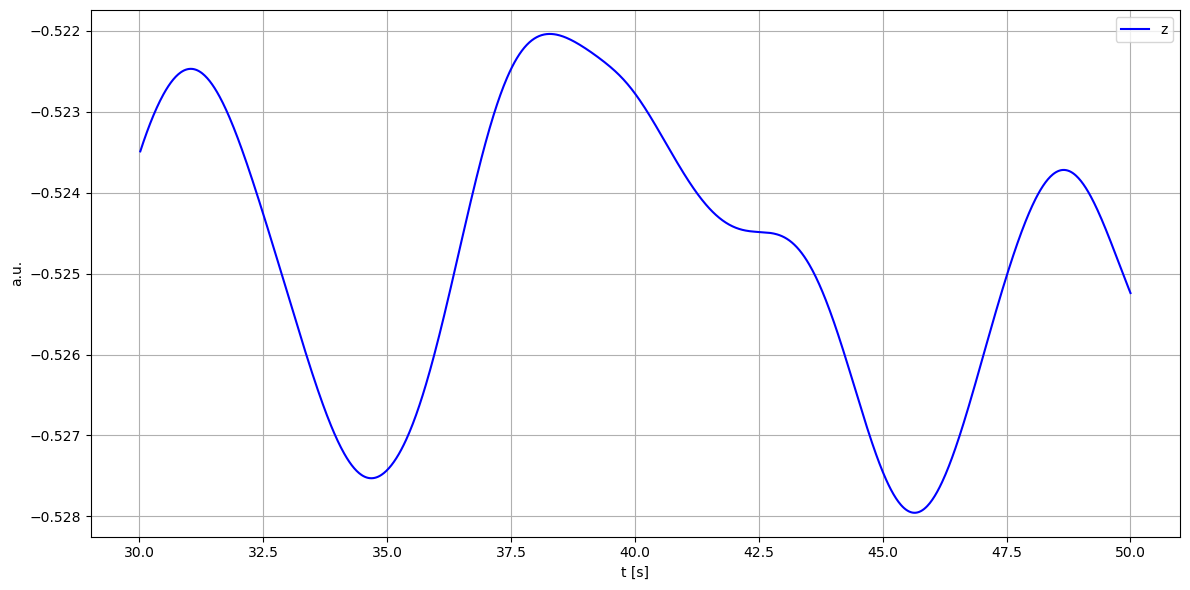

In [16]:
start=1800
t = results[start:,0]
y = results[start:,1]
z = results[start:,2]
dz = results[start:,5]
fig, ax = plt.subplots(1, figsize=(12,6))
plt.plot(t, z-z0, 'b', label="z")
ax.set_xlabel("t [s]")
ax.set_ylabel("a.u.")
plt.grid()
plt.legend()
plt.tight_layout()

In such a case we can add an integrator to the feedback loop:

In [17]:
# Vertical feedback loop with a real PID integrator.
# Gains are in SI units: position error in metres, thrust correction in
# throttle units. The Crazyflie's low thrust-to-weight ratio (~1.9)
# makes the controller less aggressive than the equivalent loop for a
# voltage-symmetric drone would be.
z_ctrl = module.PIDController(Kp=-0.1, Ki=-0.005, Kd=-0.1)


In [18]:
drone = module.Drone(name=MyName, wind=True, flight_range=(0, -3, 0, 3))
N = 3000
results = np.zeros([N,14])
V_left=0
V_right=0
phi0=np.deg2rad(0)
z0 = 1.5

z_ctrl.reset()

for i in range(N):
    state = drone.update()
    results[i,0:12] = module.state_to_array(state)
    results[i,12:14] = [V_left,V_right]

    z = state.z
    dz = state.dz
    phi = state.phi
    dphi = state.dphi

    phi_fb = phi_damped_feedback(phi, dphi, phi0)
    z_correction = z_ctrl(z, dz, z0)
    hover_ff = V_hover / np.cos(phi)        # gravity + tilt-loss feedforward
    V_left, V_right = zphi2V(hover_ff + z_correction, phi_fb)
    set_v_nohover(drone, V_left, V_right)


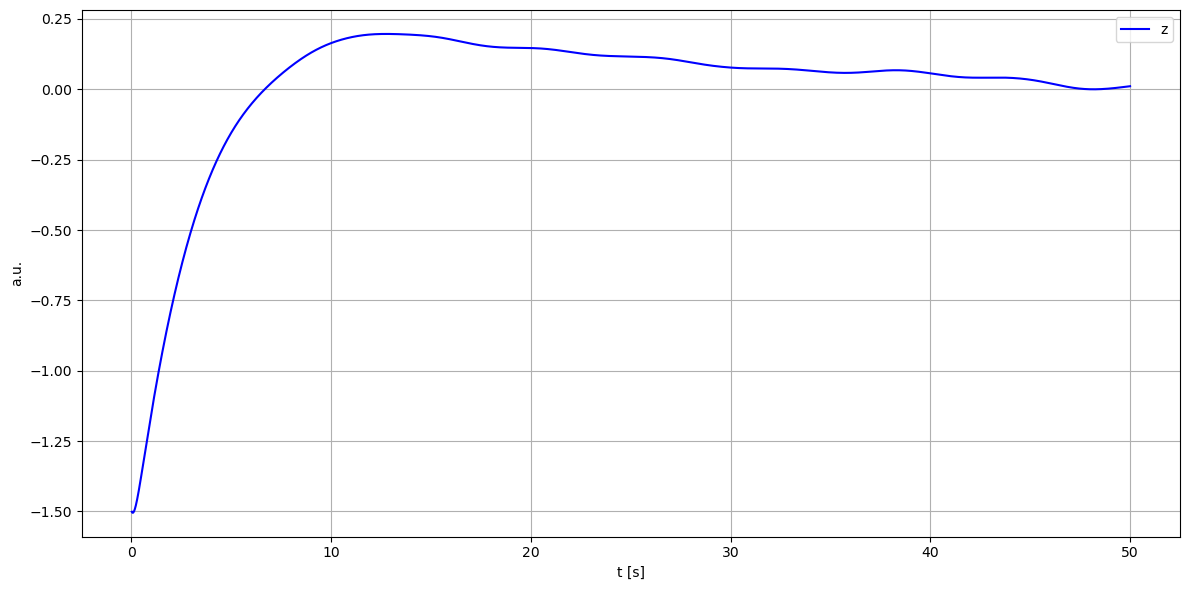

In [19]:
start=0
t = results[start:,0]
y = results[start:,1]
z = results[start:,2]
dz = results[start:,5]
fig, ax = plt.subplots(1, figsize=(12,6))
plt.plot(t, z-z0, 'b', label="z")
ax.set_xlabel("t [s]")
ax.set_ylabel("a.u.")
plt.grid()
plt.legend()
plt.tight_layout()


After fine-tuning the gains, we can get much closer to the set point (however, we cannot really reach it, the residual will be always >0). The integrator part is useful in controls with a constant or low-frequency disturbance, such as, in this case, the constat graviational force.

# Horizontal control, we need a cascaded system!

Now to complete the controller we need to add a horizontal control loop. However we have no actuator that can move the drone sideways directly. Instead we need to tilt the drone to create a sideways motion. Therefore the tilt control loop can be our actuator for the horizontal control. This means a cascaded system, in which the horizontal control is an `outer loop' and the tilt control the `inner loop'.

To test this we write yet another feedback loop, using at least proportional and differential feedback. We then use the feedback from that loop to change the set point of the tilt control loop. 

For this part we need to open up the drone ```flight_range``` to the full field of ```[-500, -500, 500, 500]```.


In [20]:
# Full cascade controllers, tuned for the Crazyflie-scale drone.
z_ctrl   = module.PIDController(Kp=-0.1, Ki=-0.005, Kd=-0.1)
y_ctrl   = module.PIDController(Kp=0.2,  Ki=0.01,   Kd=0.2)
phi_ctrl = module.PIDController(Kp=0.1,  Ki=0,      Kd=0.02)
y_clip   = 0.10 * np.pi


In [21]:
drone = module.Drone(name=MyName, wind=True, flight_range=(-3, -3, 3, 3))
N = 3000
results = np.zeros([N,14])
V_left=0
V_right=0
phi0=np.deg2rad(0)
z0 = 1.0  # m
y0 = 1.0  # m

z_ctrl.reset(); y_ctrl.reset(); phi_ctrl.reset()

for i in range(N):
    state = drone.update()
    results[i,0:12] = module.state_to_array(state)
    results[i,12:14] = [V_left,V_right]

    z = state.z; dz = state.dz
    y = state.y; dy = state.dy
    phi = state.phi; dphi = state.dphi

    z_correction = z_ctrl(z, dz, z0)
    y_fb = np.clip(y_ctrl(y, dy, y0), -y_clip, y_clip)
    phi_fb = phi_ctrl(phi, dphi, y_fb)
    hover_ff = V_hover / np.cos(phi)
    V_left, V_right = zphi2V(hover_ff + z_correction, phi_fb)
    set_v_nohover(drone, V_left, V_right)


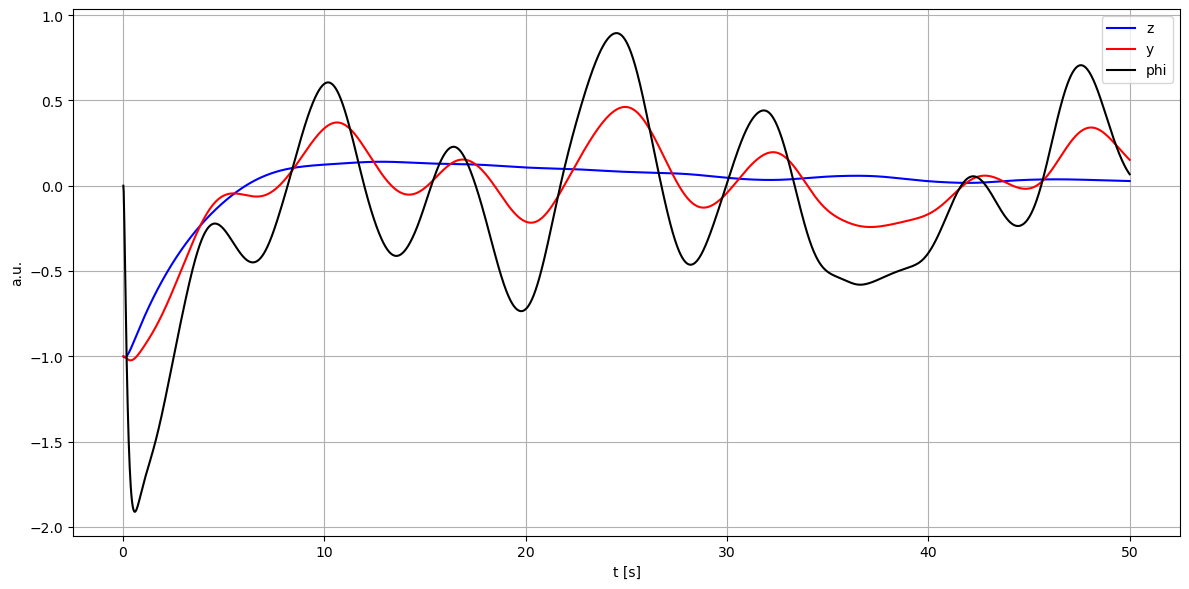

In [22]:
start=0
t = results[start:,0]
y = results[start:,1]
z = results[start:,2]
phi = results[start:,3]
fig, ax = plt.subplots(1, figsize=(12,6))
plt.plot(t, z-z0, 'b', label="z")
plt.plot(t, y-y0, 'r', label="y")
plt.plot(t, 10*phi, 'k', label="phi")
ax.set_xlabel("t [s]")
ax.set_ylabel("a.u.")
plt.grid()
plt.legend()
plt.tight_layout()

We can see that the naive combination of the feedback through the function ```zphi2V(fb_z, fb_phi)``` we created at the very top of the notebook works. But if you experiment a bit more you can also see that it has a few problems. For example, in certain conditions we can see in the flight behaviour that the direction of ```phi``` set by the y control is wrong when the vertial feedback is negativ. Similarly, the clipping of the voltage can cancel the tilt when the amount of vertical feedback is large. To address these issues you could try smarter combination. 

In the next notebooks we will use the control loops designed here. The naive signal combination and clipping will give satisfactory results. We suggest trying these first before you think about optimised control designs.  

# Improving the cascade: tilt-loss feedforward

One specific problem with the basic cascade is easy to see and easy to fix. When the drone tilts to move sideways, the *vertical* component of the lift is `F * cos(phi) / M`. So as soon as `phi` is non-zero, the lift available to hold altitude drops by a factor of `cos(phi)`, and the drone sags. The z controller then has to fight that sag reactively, which is exactly what causes the diagonal-move dip you may have noticed above.

We can pre-compensate for this by dividing the hover voltage by `cos(phi)` *before* the cascade adds its corrections. The z PID then only has to handle real altitude error, not the geometric loss from tilting.

This is still the same cascade architecture as before, with slightly stiffer outer gains. A more principled fix - solving for the `(phi, F)` that produces the desired acceleration directly, rather than patching the cascade - is the topic of `student5_model_based_control`.

In [23]:
# An improved cascade for the "advanced" demo: same architecture as the
# basic cascade in cell 29, but with stiffer outer gains and a tighter
# tilt clip, so the drone actually settles on the target instead of
# orbiting around it.
z_ctrl   = module.PIDController(Kp=-2.0, Ki=-0.1,  Kd=-1.0)
y_ctrl   = module.PIDController(Kp=0.5,  Ki=0.02,  Kd=0.3)
phi_ctrl = module.PIDController(Kp=0.1,  Ki=0,     Kd=0.02)
y_clip   = np.deg2rad(15)


In [24]:
drone = module.Drone(name=MyName, wind=True, flight_range=(-3, -3, 3, 3))
N = 3000
results = np.zeros([N, 14])
V_left = 0
V_right = 0
phi0 = np.deg2rad(0)
z0 = 1.0
y0 = 1.0

z_ctrl.reset(); y_ctrl.reset(); phi_ctrl.reset()

for i in range(N):
    state = drone.update()
    results[i, 0:12] = module.state_to_array(state)
    results[i, 12:14] = [V_left, V_right]

    z = state.z; dz = state.dz
    y = state.y; dy = state.dy
    phi = state.phi; dphi = state.dphi

    # Same cascade as before: outer y/z PIDs commanding tilt and thrust
    # correction, inner phi PD tracking the commanded tilt.
    z_correction = z_ctrl(z, dz, z0)
    y_fb = np.clip(y_ctrl(y, dy, y0), -y_clip, y_clip)
    phi_fb = phi_ctrl(phi, dphi, y_fb)

    # Tilt-loss feedforward: divide hover by cos(phi) so the geometric
    # lift loss from tilting is compensated before the z PID gets a say.
    hover_ff = V_hover / np.cos(phi)
    V_left, V_right = zphi2V(hover_ff + z_correction, phi_fb)
    set_v(drone, V_left, V_right)

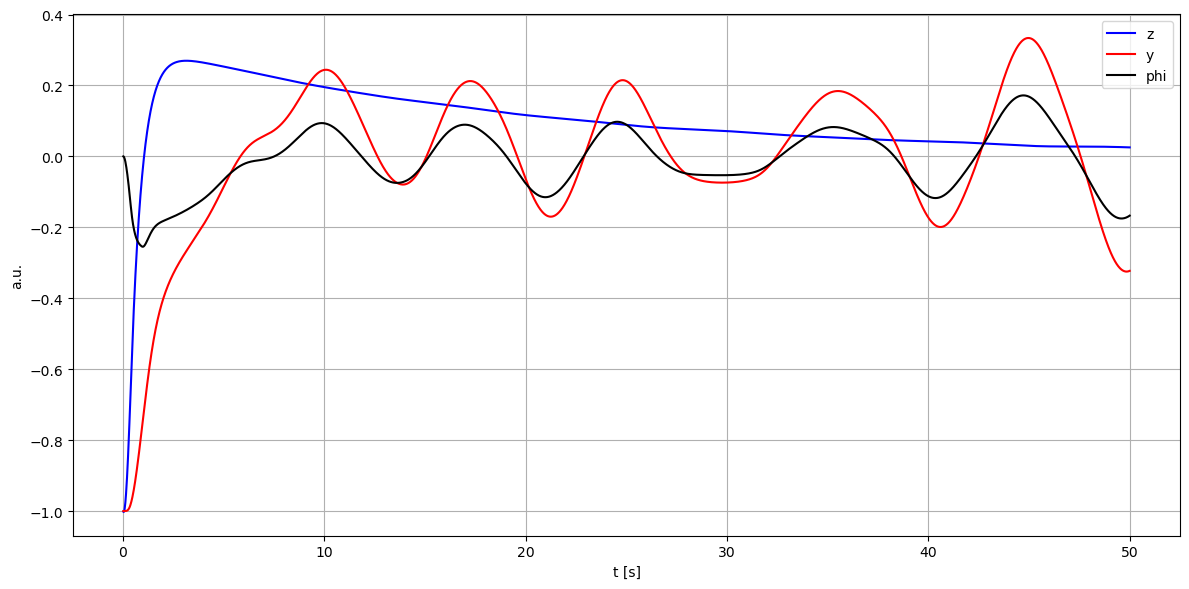

In [25]:
start=0
t = results[start:,0]
y = results[start:,1]
z = results[start:,2]
phi = results[start:,3]
fig, ax = plt.subplots(1, figsize=(12,6))
plt.plot(t, z-z0, 'b', label="z")
plt.plot(t, y-y0, 'r', label="y")
plt.plot(t, phi, 'k', label="phi")
ax.set_xlabel("t [s]")
ax.set_ylabel("a.u.")
plt.grid()
plt.legend()
plt.tight_layout()